# YOLO Training Visualization

Compare **train/box_loss** vs **val/box_loss** across epochs.

- If both decrease together → model is learning well.
- If train drops but val stalls or rises → overfitting.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training results
df = pd.read_csv('100_epochs_results.csv')
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,639.384,1.56349,7.92257,0.01028,0.70837,0.67994,0.71479,0.35629,1.68729,1.69170,0.01374,0.000415,0.000415,0.000415
1,2,1266.910,1.62838,1.44905,0.01160,0.70983,0.64881,0.69525,0.34617,1.72825,1.40128,0.01423,0.000790,0.000790,0.000790
2,3,1903.110,1.66233,1.34857,0.01209,0.68259,0.55878,0.61422,0.30835,1.81746,1.74502,0.01628,0.001125,0.001125,0.001125
3,4,630.165,1.63291,1.27759,0.01174,0.77623,0.72967,0.80617,0.42584,1.60651,1.11538,0.01261,0.001064,0.001064,0.001064
4,5,1246.150,1.56781,1.13412,0.01112,0.83538,0.76741,0.85026,0.48550,1.50690,0.89266,0.01176,0.001002,0.001002,0.001002


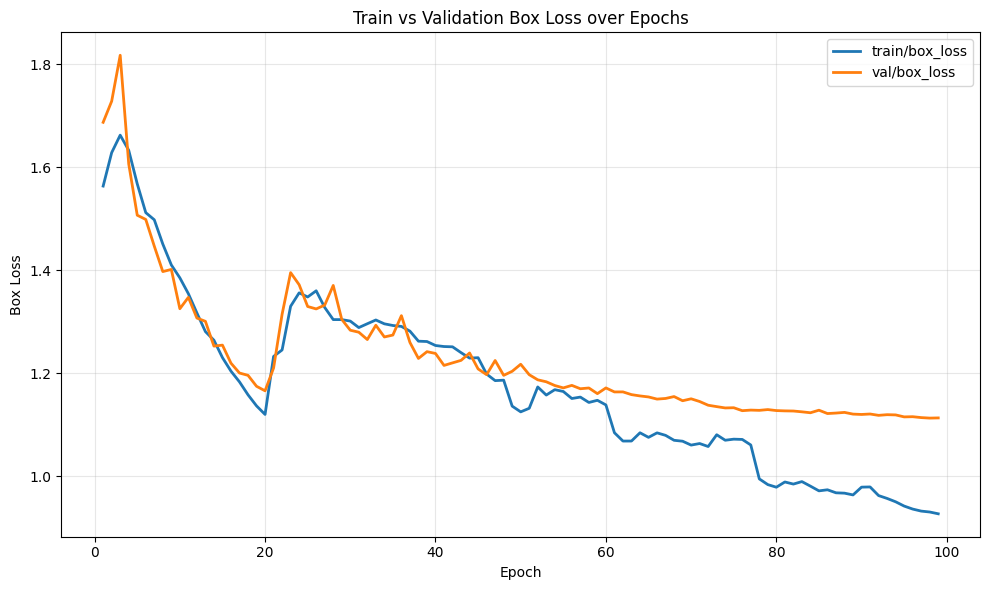

In [18]:
# Plot train vs val box loss on the same graph
plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['train/box_loss'], label='train/box_loss', color='tab:blue', linewidth=2)
plt.plot(df['epoch'], df['val/box_loss'], label='val/box_loss', color='tab:orange', linewidth=2)

plt.title('Train vs Validation Box Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Box Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Insights from Box Loss graph

- **Epochs 1–20:** Both losses drop together from ~1.7 to ~1.15 — model is learning well, no overfitting yet.
- **Epoch ~22 bump:** Brief instability, likely from a training resume (the `time` column swings wildly between epochs 3 and 4, suggesting a pause). Recovers fine.
- **Epochs 60–99:** Train keeps falling (~0.93), val flattens (~1.11). Widening gap = **mild overfitting**.

**Takeaways:**
- Best checkpoint maybe in the **60–80 range**, not the final epoch.

## Train vs Validation Classification Loss

`cls_loss` measures how well the model assigns the correct class label to detected objects.

- Both should trend down together.
- A widening gap (train low, val high) suggests the model is memorizing class patterns instead of generalizing.

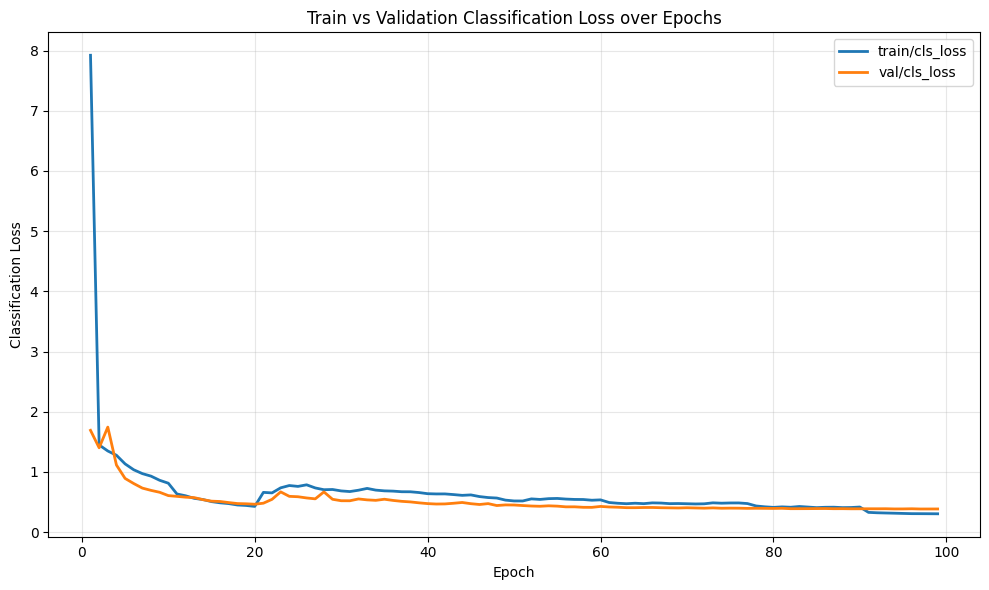

In [19]:
# Plot train vs val classification loss on the same graph
plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['train/cls_loss'], label='train/cls_loss', color='tab:blue', linewidth=2)
plt.plot(df['epoch'], df['val/cls_loss'], label='val/cls_loss', color='tab:orange', linewidth=2)

plt.title('Train vs Validation Classification Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Classification Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Insights from Classification Loss graph

- **Epoch 1 spike (~7.9):** Random init noise. Drops to normal by epoch 2 — ignore.
- **Epochs 2–20:** Train and val fall together from ~1.5 to ~0.5 — clean learning.
- **Epoch ~22 bump:** Brief instability (same as in box loss). Recovers fine.
- **Epochs 30–99:** Both flatten. Val sits *below* train (normal — augmentation makes train harder than val).

**Takeaway:** Classification is healthy and not the bottleneck. The mild overfitting in box_loss is about localization, not class prediction. The model knows *what* objects are, just getting slightly sloppy about *where* on the training set.


## Train vs Validation DFL Loss

`dfl_loss` (Distribution Focal Loss) refines bounding box edges for finer localization.

- A complement to `box_loss`. Both should fall together.
- A flat or rising val curve while train falls signals overfitting on box geometry.

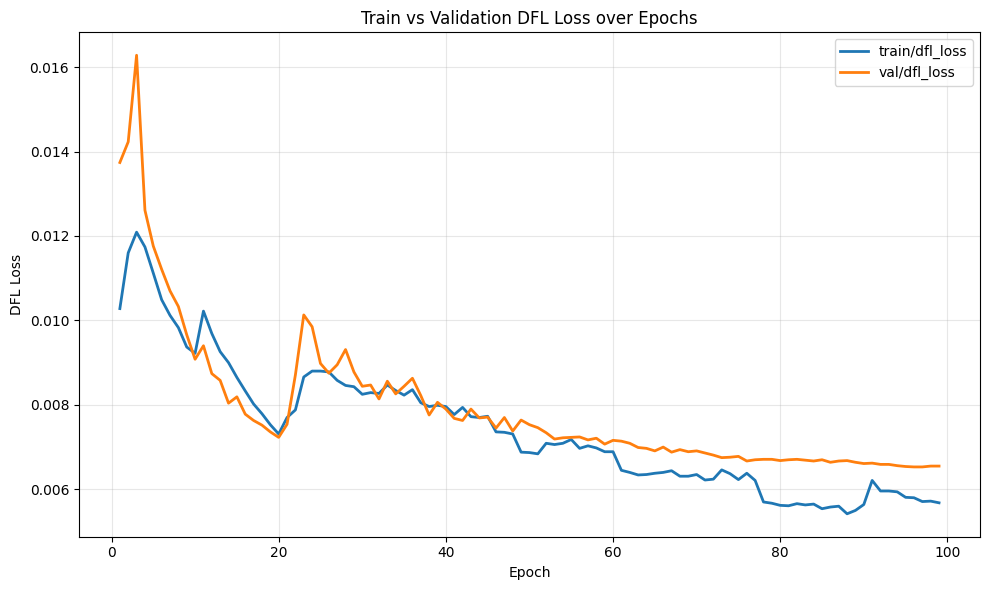

In [20]:
# Plot train vs val DFL loss on the same graph
plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['train/dfl_loss'], label='train/dfl_loss', color='tab:blue', linewidth=2)
plt.plot(df['epoch'], df['val/dfl_loss'], label='val/dfl_loss', color='tab:orange', linewidth=2)

plt.title('Train vs Validation DFL Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('DFL Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## mAP50 over Epochs

`mAP50(B)` is the primary detection scoreboard: mean Average Precision at IoU 0.5 for bounding boxes.

- Higher is better (range 0 to 1).
- Should rise and plateau. A drop late in training often signals overfitting.

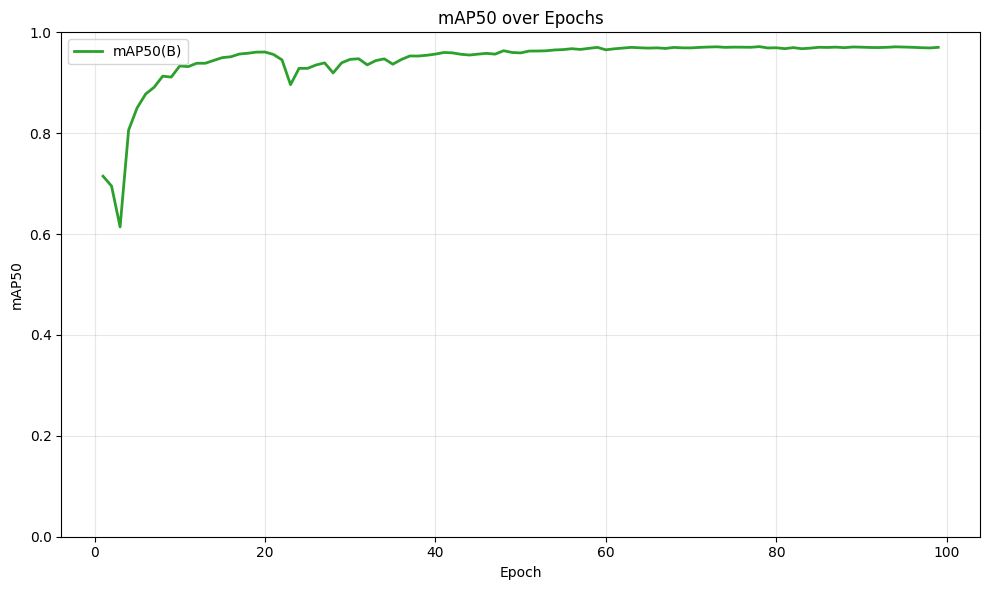

In [21]:
# Plot mAP50 over epochs
plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50(B)', color='tab:green', linewidth=2)

plt.title('mAP50 over Epochs')
plt.xlabel('Epoch')
plt.ylabel('mAP50')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## mAP50-95 over Epochs

`mAP50-95(B)` averages mAP across IoU thresholds from 0.5 to 0.95 in steps of 0.05. It rewards tighter, more precise bounding boxes.

- Always ≤ mAP50 (it's a stricter measure).
- A small gap with mAP50 means boxes are well-localized.
- A large gap means boxes are roughly right but loose around the object.

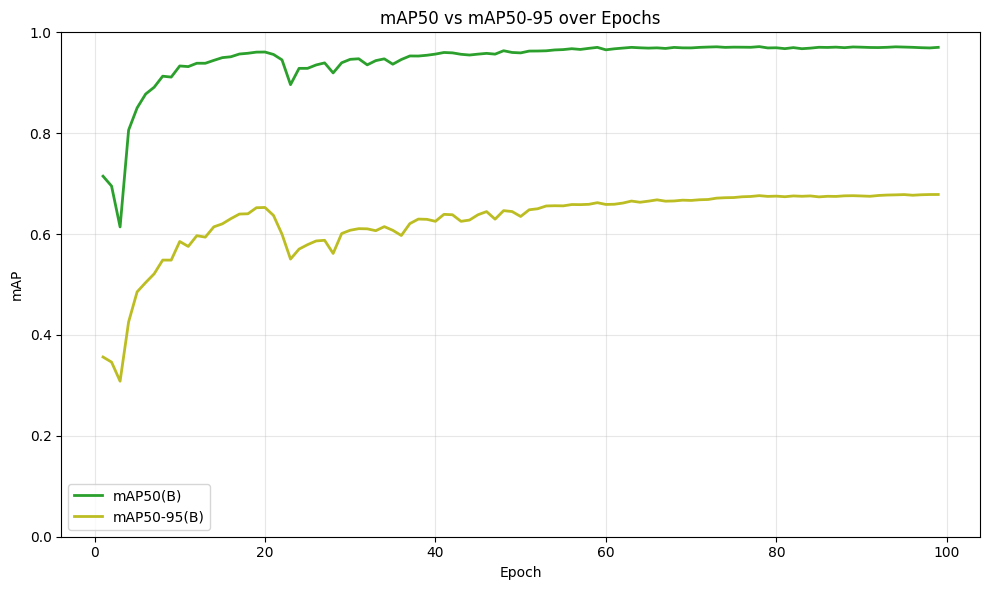

In [22]:
# Plot mAP50-95 over epochs (alongside mAP50 for context)
plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50(B)', color='tab:green', linewidth=2)
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95(B)', color='tab:olive', linewidth=2)

plt.title('mAP50 vs mAP50-95 over Epochs')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Insights from mAP graph

- **mAP50 ≈ 0.97, mAP50-95 ≈ 0.68** at epoch 99. Strong detection, decent localization.
- **Rapid climb in epochs 1–5,** then steady gains through the rest of training.
- **Epoch ~22 dip:** Brief instability (same as in loss graphs). Recovers fine.
- **Persistent ~0.29 gap** between mAP50 and mAP50-95 = boxes find objects but don't hug them tightly. 


## Precision vs Recall over Epochs

- **Precision** — of predicted boxes, what fraction were correct (low false positives).
- **Recall** — of real objects, what fraction were detected (low false negatives).

What to look for:
- Both rising together → model is genuinely improving.
- One rising while the other falls → confidence threshold is skewed (too strict or too loose).
- Both flat → training has stalled.

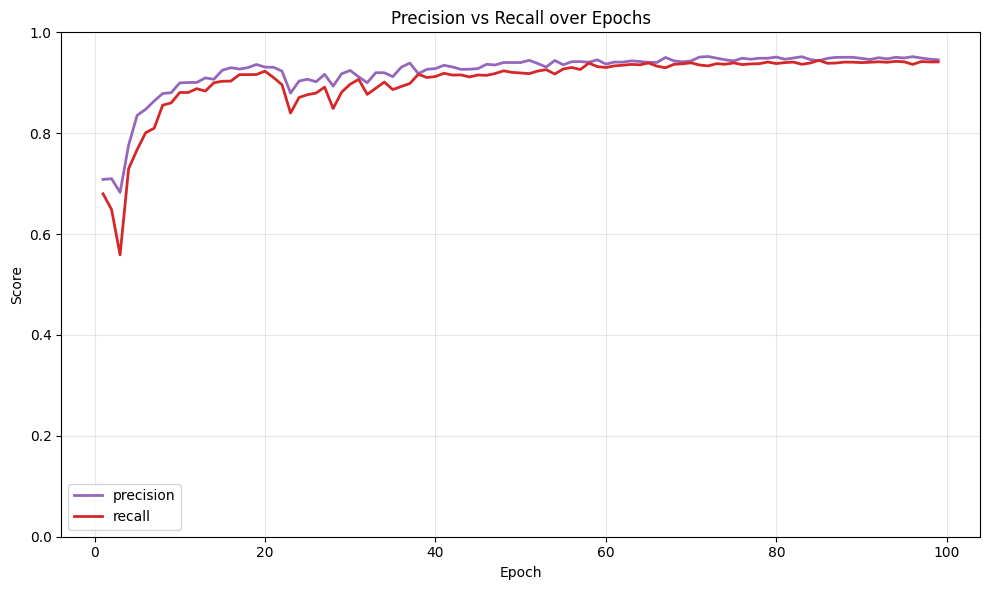

In [23]:
# Plot precision vs recall over epochs
plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='precision', color='tab:purple', linewidth=2)
plt.plot(df['epoch'], df['metrics/recall(B)'], label='recall', color='tab:red', linewidth=2)

plt.title('Precision vs Recall over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Insights from Precision vs Recall graph

- **Both end ~0.94** at epoch 99 — balanced and high.
- **Precision slightly above recall** throughout — healthy "confident before predicting" bias.
- **Lines hug each other** — no divergence between false positives and false negatives.
- **Epoch ~22 dip:** Recall dips slightly more than precision during a brief instability. Recovers fast.
